# Comparing a stitched `glo_30` with the NISAR DEM

The [NISAR DEM v1.2](https://nisar-docs.asf.alaska.edu/nisar-dem/) is the Copernicus GLO-30 (2023_1) re-referenced to the WGS84 ellipsoid by JPL (EGM2008 removed at the source). It therefore serves as an independent reference for the stitcher geoid handling: stitching `glo_30` with `dst_ellipsoidal_height=True` and `dst_area_or_point='Point'` should reproduce the NISAR DEM on the native Copernicus lattice.

Prior to the fix of [issue #151](https://github.com/ACCESS-Cloud-Based-InSAR/dem-stitcher/issues/151), the 'Point' path shifted the geoid by half a *geoid* pixel (~30 arcseconds) rather than half a *DEM* pixel, biasing ellipsoidal heights by up to several centimeters wherever the geoid has a gradient.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dem_stitcher import stitch_dem

Global variables defining the comparison.

In [2]:
BOUNDS = [-118.8, 34.6, -118.5, 34.8]
DST_AREA_OR_POINT = 'Point'
CMAP = 'RdBu_r'
DIFF_LIM_M = 0.01

In [3]:
X_nisar, p_nisar = stitch_dem(BOUNDS, 'nisar_dem', dst_area_or_point=DST_AREA_OR_POINT)
X_glo, p_glo = stitch_dem(BOUNDS, 'glo_30', dst_ellipsoidal_height=True, dst_area_or_point=DST_AREA_OR_POINT)
assert p_nisar['transform'] == p_glo['transform']
p_nisar['transform']

Opening nisar_dem Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Opening nisar_dem Datasets: 100%|██████████| 1/1 [00:06<00:00,  6.31s/it]

Opening nisar_dem Datasets: 100%|██████████| 1/1 [00:06<00:00,  6.31s/it]

Reading tile metadata:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile metadata: 100%|██████████| 1/1 [00:00<00:00, 329.38it/s]

...

Reading tile metadata: 100%|██████████| 1/1 [00:00<00:00, 403.88it/s]

Reading tile imagery:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile imagery: 100%|██████████| 1/1 [00:03<00:00,  3.27s/it]

Reading tile imagery: 100%|██████████| 1/1 [00:03<00:00,  3.27s/it]

Affine(0.0002777777777777778, 0.0, -118.80013888888888,
       0.0, -0.0002777777777777778, 34.80013888888889)

The grids align exactly. The remaining difference is the EGM2008 model/resolution difference between the geoid grid used by JPL and the 1 arcminute agisoft EGM2008 grid used here (plus `float32` rounding and any Copernicus 2021 vs 2023_1 tile updates).

In [4]:
diff = X_nisar - X_glo
{'mean_m': float(np.nanmean(diff)), 'std_m': float(np.nanstd(diff)), 'max_abs_m': float(np.nanmax(np.abs(diff)))}

{'mean_m': -0.00023940512619446963,
 'std_m': 0.001135644386522472,
 'max_abs_m': 0.0029296875}

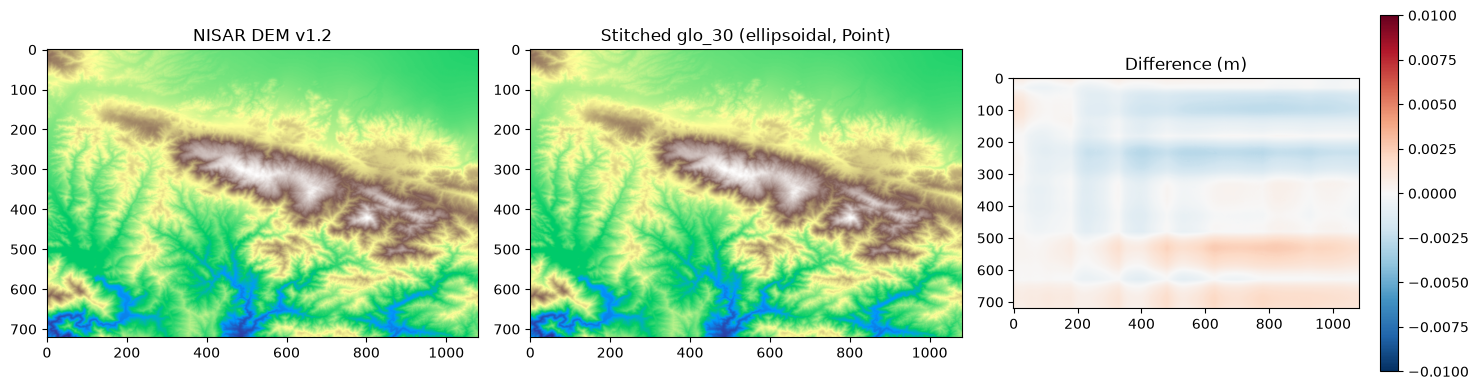

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(X_nisar, cmap='terrain')
axes[0].set_title('NISAR DEM v1.2')
axes[1].imshow(X_glo, cmap='terrain')
axes[1].set_title('Stitched glo_30 (ellipsoidal, Point)')
im = axes[2].imshow(diff, cmap=CMAP, vmin=-DIFF_LIM_M, vmax=DIFF_LIM_M)
axes[2].set_title('Difference (m)')
fig.colorbar(im, ax=axes[2])
plt.tight_layout()

Text(0, 0.5, 'pixel count')

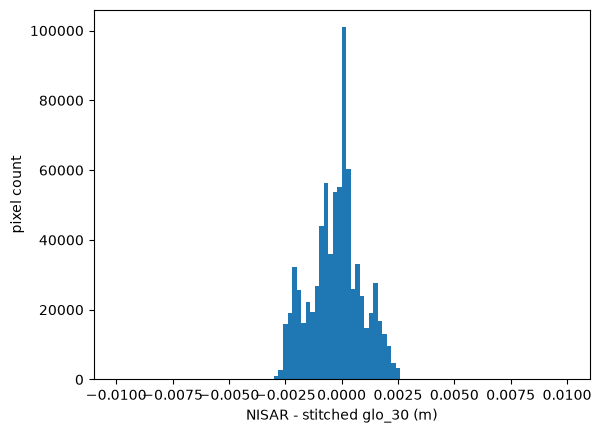

In [6]:
plt.hist(diff.ravel(), bins=100, range=(-DIFF_LIM_M, DIFF_LIM_M))
plt.xlabel('NISAR - stitched glo_30 (m)')
plt.ylabel('pixel count')